In [1]:
!unzip recordings.zip

Archive:  recordings.zip
   creating: recordings/
  inflating: recordings/4_lucas_12.wav  
  inflating: recordings/0_jackson_14.wav  
  inflating: recordings/0_jackson_15.wav  
  inflating: recordings/0_jackson_16.wav  
  inflating: recordings/0_jackson_17.wav  
  inflating: recordings/0_jackson_18.wav  
  inflating: recordings/0_jackson_19.wav  
  inflating: recordings/0_jackson_2.wav  
  inflating: recordings/0_jackson_20.wav  
  inflating: recordings/0_jackson_21.wav  
  inflating: recordings/0_jackson_22.wav  
  inflating: recordings/0_jackson_23.wav  
  inflating: recordings/0_jackson_24.wav  
  inflating: recordings/0_jackson_25.wav  
  inflating: recordings/0_jackson_26.wav  
  inflating: recordings/0_jackson_27.wav  
  inflating: recordings/0_jackson_28.wav  
  inflating: recordings/0_jackson_29.wav  
  inflating: recordings/0_jackson_3.wav  
  inflating: recordings/0_jackson_30.wav  
  inflating: recordings/0_jackson_31.wav  
  inflating: recordings/0_jackson_32.wav  
  inflat

In [2]:
import os

dataset_path = "recordings"
files = os.listdir(dataset_path)
print("Total files:", len(files))
print(files[:5])

Total files: 3000
['8_theo_29.wav', '8_jackson_32.wav', '9_yweweler_18.wav', '3_nicolas_12.wav', '0_yweweler_26.wav']


In [3]:
!pip install librosa

import os
import numpy as np
import librosa
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
dataset_path = "recordings"
files = os.listdir(dataset_path)

X = []
y = []

for file in files:
    file_path = os.path.join(dataset_path, file)

    signal, sr = librosa.load(file_path, sr=None)  # keep 8kHz

    mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=40,
    n_fft=512,
    hop_length=256)

    X.append(mfcc)

    digit = int(file.split("_")[0])
    y.append(digit)

print("Total samples:", len(X))
print("Shape of one MFCC:", X[2656].shape)



Total samples: 3000
Shape of one MFCC: (40, 14)


In [8]:
print("Shape of one MFCC:", X[26].shape)

Shape of one MFCC: (40, 16)


In [9]:
max_len = max(mfcc.shape[1] for mfcc in X)
print("Max time frames:", max_len)

Max time frames: 72


In [10]:
X_padded = []

for mfcc in X:
    pad_width = max_len - mfcc.shape[1]
    mfcc_padded = np.pad(mfcc,
                         pad_width=((0,0),(0,pad_width)),
                         mode='constant')
    X_padded.append(mfcc_padded)

X = np.array(X_padded)
y = np.array(y)

print("Final shape:", X.shape)

Final shape: (3000, 40, 72)


In [11]:
num_samples, n_mfcc, time_steps = X.shape

X_reshaped = X.reshape(num_samples, -1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(num_samples, n_mfcc, time_steps)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.17, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2489, 40, 72)
Test shape: (511, 40, 72)


In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape)

torch.Size([2489, 1, 40, 72])


In [14]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.3)

        # We must calculate flatten size dynamically
        self._to_linear = None
        self._get_conv_output()

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, 10)   # 10 digits (0-9)

    def _get_conv_output(self):
        x = torch.randn(1, 1, 40, X_train.shape[3])
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        self._to_linear = x.numel()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=5760, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [19]:
import matplotlib.pyplot as plt

epochs = 15

train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    # -------- Test Accuracy ----------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Test Acc: {test_acc:.2f}%")

Epoch [1/15] Loss: 0.1346 Train Acc: 96.58% Test Acc: 96.67%
Epoch [2/15] Loss: 0.0857 Train Acc: 97.95% Test Acc: 97.46%
Epoch [3/15] Loss: 0.0665 Train Acc: 98.43% Test Acc: 98.04%
Epoch [4/15] Loss: 0.0988 Train Acc: 97.43% Test Acc: 98.04%
Epoch [5/15] Loss: 0.0669 Train Acc: 98.27% Test Acc: 97.85%
Epoch [6/15] Loss: 0.0695 Train Acc: 98.11% Test Acc: 97.46%
Epoch [7/15] Loss: 0.1021 Train Acc: 97.71% Test Acc: 92.17%
Epoch [8/15] Loss: 0.1474 Train Acc: 96.91% Test Acc: 94.72%
Epoch [9/15] Loss: 0.0968 Train Acc: 97.55% Test Acc: 98.43%
Epoch [10/15] Loss: 0.0810 Train Acc: 97.87% Test Acc: 98.24%
Epoch [11/15] Loss: 0.0557 Train Acc: 98.35% Test Acc: 96.87%
Epoch [12/15] Loss: 0.0691 Train Acc: 97.95% Test Acc: 97.46%
Epoch [13/15] Loss: 0.0649 Train Acc: 98.19% Test Acc: 97.65%
Epoch [14/15] Loss: 0.0636 Train Acc: 98.19% Test Acc: 98.24%
Epoch [15/15] Loss: 0.1180 Train Acc: 97.11% Test Acc: 96.67%


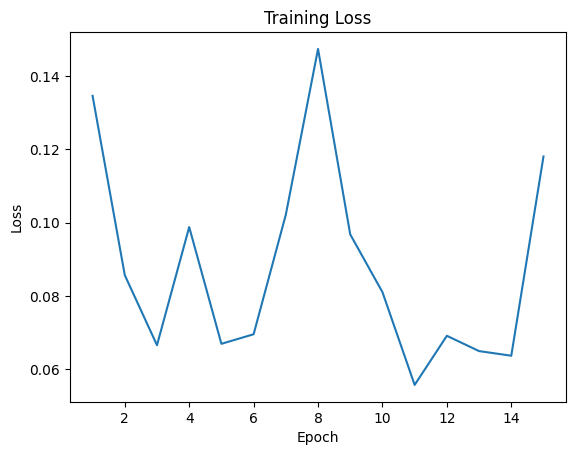

In [20]:
plt.figure()
plt.plot(range(1, epochs+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

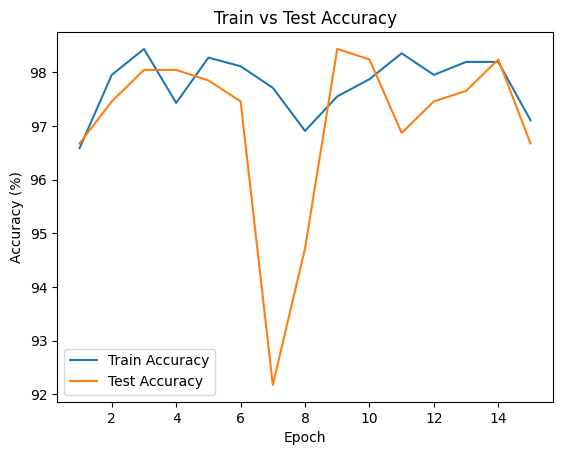

In [21]:
plt.figure()
plt.plot(range(1, epochs+1), train_accuracies)
plt.plot(range(1, epochs+1), test_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy")
plt.legend(["Train Accuracy", "Test Accuracy"])
plt.show()